<a href="https://colab.research.google.com/github/stfnnnnnnn/karl-mangahas-flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/stfnnnnnnn/1st-act/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

> **Among pages with sufficient historical evidence that appear stable at the decision point, which pages should a content manager review first because they show elevated risk of a later visibility decline?**

>This question comes directly from the FlyRank content-review problem: review capacity is limited, while search performance can weaken across a large portfolio of pages. The objective is therefore not simply to identify pages after they have declined. It is to use historical, decision-time-safe evidence to **rank which apparently stable pages deserve earlier human review**.

### Decision supported

>The model produces a continuous review-priority score. Higher scores move pages earlier in the queue, but they do **not** prescribe an editorial action.

The intended workflow is:

**Prioritize → Inspect → Diagnose → Decide**

>A reviewer may ultimately act, monitor, protect, or dismiss a recommendation. The model does not automatically refresh, rewrite, merge, redirect, delete, or change metadata.

### Claim boundary

>The project evaluates whether historical search behavior provides **observed, measured, directional value for review prioritization**. It does not claim to predict Google's algorithm, identify the cause of decline, or prove that editing a surfaced page will recover traffic.

In [1]:
PROJECT = {
    "unit_of_analysis": "one pseudonymized content page",
    "decision_output": "continuous decline-risk score used to rank a human-review queue",
    "primary_selection_metric": "mean client-grouped CV Average Precision",
    "human_review_required": True,
}
PROJECT


{'unit_of_analysis': 'one pseudonymized content page',
 'decision_output': 'continuous decline-risk score used to rank a human-review queue',
 'primary_selection_metric': 'mean client-grouped CV Average Precision',
 'human_review_required': True}

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Release and source tables

The final analysis uses the pseudonymized **FlyRank ML Internship warehouse**:

- warehouse source: `hf://datasets/FlyRank/internship-warehouse`
- recorded build: `flyrank_pseudonymized_warehouse_release_v20260703`
- `fact_content_daily_performance` — daily Google Search Console impressions, clicks, and average position
- `dim_clients` — client-level GSC tracking start used to verify sufficient history before the feature window

The broader warehouse contains approximately **78.8 million daily performance rows**, **519,606 content items**, and **104 clients**. The final development population is intentionally smaller because it applies the eligibility rules below.

### Final development timeline

- historical feature start: **December 1, 2025**
- decision point: **March 1, 2026**
- development endpoint: **March 31, 2026**
- historical evidence: **90 days**, divided into three 30-day blocks
- observed outcome: a separate **later 30-day window**

The three historical blocks preserve both historical levels and pre-decision movement. The later outcome window is kept separate from the predictive feature set.

### Eligibility

A page enters the final development population only when it has:

- at least **100 recent historical impressions**;
- at least **60 observed history days**;
- GSC tracking that predates the historical feature window; and
- recent historical impressions within **±20%** of the preceding historical block.

This produces **16,183 eligible pages across 24 clients**, with an overall eligible decline rate of approximately **28.58%**.

The stability rule is deliberately narrow. “Stable at the decision point” means stable under the declared impressions-based eligibility rule; it does not certify content quality, intent fit, ranking health, or future performance.

### Public-safe exclusions

Outcome-period measurements, the decline outcome itself, client/content identifiers, and existing product decision flags are excluded from the predictive feature set. IDs are retained only where needed for grouping, joining, and pseudonymized reviewer traceability.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = "https://raw.githubusercontent.com/stfnnnnnnn/karl-mangahas-flyrank/main"
LOCAL_OUTPUTS = Path("work/outputs")
LOCAL_FIGURES = Path("work/figures")

def load_csv(name):
    local = LOCAL_OUTPUTS / name
    if local.exists():
        return pd.read_csv(local)
    return pd.read_csv(f"{REPO}/work/outputs/{name}")

data_receipt = {
    "historical_feature_start": "2025-12-01",
    "decision_date": "2026-03-01",
    "development_endpoint": "2026-03-31",
    "eligible_pages": 16183,
    "eligible_clients": 24,
    "eligible_decline_base_rate": 0.2858,
}
pd.Series(data_receipt, name="value").to_frame()


,value
historical_feature_start,2025-12-01
decision_date,2026-03-01
development_endpoint,2026-03-31
eligible_pages,16183
eligible_clients,24
eligible_decline_base_rate,0.2858


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Task and label

The observed outcome is binary:

`is_declining = 1` when `imp_outcome30 < 0.80 × imp_recent30`

>In other words, a page is labeled as declining when impressions in the later 30-day outcome window fall by more than 20% relative to the most recent historical 30-day block.

>Although the observed label is binary, the practical task is **ranking**. Predicted probabilities are used as continuous review-priority scores rather than as automatic positive/negative editorial decisions.

### Historical predictors

The final model uses 14 leakage-audited historical predictors:

- `imp_early30`
- `imp_middle30`
- `imp_recent30`
- `clk_recent30`
- `pos_recent30`
- `imp_change_middle_vs_early`
- `imp_change_recent_vs_middle`
- `ctr_middle30`
- `ctr_recent30`
- `ctr_change_recent_vs_middle`
- `pos_change_recent_vs_middle`
- `days_with_impressions_90`
- `imp_cv_90`
- `recent_position_available`

>These features describe historical visibility, clicks, CTR, average position, historical movement, coverage, and variability before the outcome window.

### Baseline

>The transparent comparator combines historical impression weakening, historical position deterioration, and meaningful visibility into an interpretable review-priority score. Its preprocessing parameters and normalization values are estimated from training clients only before scoring held-out clients.

>The baseline is intentionally meaningful rather than weak: a learned model should earn its added complexity under the same evaluation design.

### Candidate models

The final comparison includes:

1. transparent historical baseline;
2. Logistic Regression;
3. Random Forest; and
4. HistGradientBoosting.

>Random Forest is appropriate as a learned candidate because relationships among historical impressions, clicks, CTR, position, and their changes are not assumed to be purely linear. It also provides fitted feature-importance diagnostics, while remaining interpretable enough for a decision-support workflow.

### Validation and selection

>Model selection uses **five-fold `GroupKFold` by client**. Entire clients are held out so pages from the same client do not appear in both training and validation within a fold.

The predeclared selection rule is:

> **Select the learned model with the highest mean grouped-CV Average Precision.**

>Precision@20 and Precision@50 are supporting operational metrics because they match limited review capacity. The selected model is described as operationally useful only when mean Precision@50 exceeds both the contemporary mean fold base rate and the transparent baseline.

>A separate fixed **six-client grouped holdout** is used for queue construction, concrete error examples, and client-level diagnostics. It does not replace grouped cross-validation as the model-selection evidence.

### Leakage checks

- outcome-period measurements are excluded from predictors;
- the outcome label is excluded from predictors;
- client/content IDs are not predictive features;
- median imputation is fitted inside each training fold or training partition;
- baseline medians and normalization parameters are estimated from training clients only; and
- grouped validation prevents train/validation client overlap.


In [3]:
FEATURE_COLS = [
    "imp_early30", "imp_middle30", "imp_recent30", "clk_recent30", "pos_recent30",
    "imp_change_middle_vs_early", "imp_change_recent_vs_middle",
    "ctr_middle30", "ctr_recent30", "ctr_change_recent_vs_middle",
    "pos_change_recent_vs_middle", "days_with_impressions_90",
    "imp_cv_90", "recent_position_available",
]

method_receipt = {
    "label": "imp_outcome30 < 0.80 * imp_recent30",
    "feature_count": len(FEATURE_COLS),
    "grouped_cv_folds": 5,
    "grouping_key": "client_hash_id",
    "selection_rule": "highest mean grouped-CV Average Precision among learned models",
    "fixed_holdout_clients": 6,
    "train_test_client_overlap": 0,
}
pd.Series(method_receipt, name="value").to_frame()


,value
label,imp_outcome30 < 0.80 * imp_recent30
feature_count,14
grouped_cv_folds,5
grouping_key,client_hash_id
selection_rule,highest mean grouped-CV Average Precision amon...
fixed_holdout_clients,6
train_test_client_overlap,0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Grouped cross-validation

All methods are compared under the same final Week 7 population and client-grouped validation design.

| Method | Mean AP | Precision@20 | Precision@50 |
|---|---:|---:|---:|
| Transparent baseline | 0.3476 | 32.0% | 34.4% |
| Logistic Regression | 0.3171 | 33.0% | 30.4% |
| **Random Forest** | **0.3616** | **39.0%** | **36.8%** |
| HistGradientBoosting | 0.3575 | 32.0% | 35.2% |

The mean fold decline base rate is **30.04%**.

Random Forest is carried forward because it achieved the highest mean grouped-CV Average Precision under the predeclared selection rule. In the final execution, it also leads the learned alternatives at Precision@20 and Precision@50.

Relative to the mean fold base rate, Random Forest achieved approximately:

- **1.36× mean lift@20**
- **1.30× mean lift@50**

The improvement over the transparent baseline is measurable but modest: mean AP increases from **0.3476 to 0.3616**, while mean Precision@50 increases from **34.4% to 36.8%**.

### Variability

The averages do not tell the whole story. Random Forest's grouped-CV Average Precision has a standard deviation of approximately **0.1585**, while Precision@50 has a standard deviation of approximately **18.85 percentage points**.

Precision@50 lift ranges from approximately **0.69× to 2.01× across folds**, showing that transfer varies substantially across held-out client compositions.

### Fixed grouped holdout

On the fixed six-client holdout, Random Forest achieved:

- ROC-AUC: **0.620**
- Average Precision: **0.3207**
- Precision@20: **40%**
- Precision@50: **40%**
- holdout base rate: **24.02%**

HistGradientBoosting remained competitive, including slightly higher holdout AP (**0.3210**) and the same Precision@50 (**40%**). This is why the fixed holdout is treated as a diagnostic rather than as a reason to replace the grouped-CV selection rule.

,method,mean_ap,precision_at_20,precision_at_50
0,Transparent baseline,0.3476,32.0%,34.4%
1,Logistic Regression,0.3171,33.0%,30.4%
2,Random Forest,0.3616,39.0%,36.8%
3,HistGradientBoosting,0.3575,32.0%,35.2%


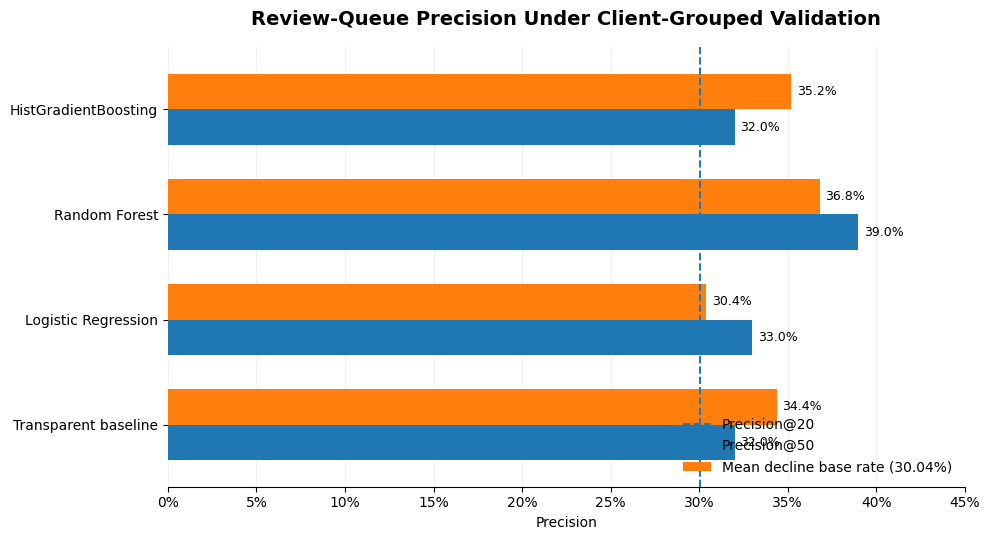

In [8]:
final_cv = pd.DataFrame([
    ["Transparent baseline", 0.3476, 0.320, 0.344],
    ["Logistic Regression", 0.3171, 0.330, 0.304],
    ["Random Forest", 0.3616, 0.390, 0.368],
    ["HistGradientBoosting", 0.3575, 0.320, 0.352],
], columns=[
    "method",
    "mean_ap",
    "precision_at_20",
    "precision_at_50",
])

display(
    final_cv.style.format({
        "mean_ap": "{:.4f}",
        "precision_at_20": "{:.1%}",
        "precision_at_50": "{:.1%}",
    })
)

plot_df = final_cv.set_index("method")[
    ["precision_at_20", "precision_at_50"]
]

ax = plot_df.plot(
    kind="barh",
    figsize=(10, 5.5),
    width=0.68,
)

ax.axvline(
    0.3004,
    linestyle="--",
    linewidth=1.4,
    label="Mean decline base rate (30.04%)",
)

ax.set_title(
    "Review-Queue Precision Under Client-Grouped Validation",
    fontsize=14,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel("Precision")
ax.set_ylabel("")

ax.set_xlim(0, 0.45)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:.0%}"
    )
)

ax.legend(
    ["Precision@20", "Precision@50", "Mean decline base rate (30.04%)"],
    frameon=False,
    loc="lower right",
)

ax.grid(
    axis="x",
    alpha=0.18,
)

ax.set_axisbelow(True)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{bar.get_width():.1%}"
            for bar in container
        ],
        padding=4,
        fontsize=9,
    )

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

The final results support a **development-stage human-review prioritization model**, not a production-ready autonomous system.

1. **Not a sealed future-month test.** Grouped validation tests transfer across held-out clients, not stability across an untouched future calendar period.
2. **The label is operational, not causal.** A greater-than-20% impression decline describes what happened, not why it happened.
3. **Important context is unobserved.** Seasonality, intent changes, competition, editorial work, SERP changes, query mix, and client-specific events can affect outcomes.
4. **No intervention claim.** A high score does not show that refreshing, rewriting, consolidating, or otherwise editing the page will reverse the observed risk.
5. **Performance varies across clients.** Fold-level results show substantial dispersion, including Precision@50 lift below 1.0× in one grouped fold.
6. **Model differences remain modest.** Random Forest leads the final grouped-CV AP, P@20, and P@50 results, but HistGradientBoosting remains a competitive nonlinear alternative.

The safest conclusion is:

> **Historical search behavior provides measurable but variable value for prioritizing apparently stable pages for earlier human review. The evidence supports directional decision support, not autonomous editorial action or universal future-period reliability.**

In [5]:
limitations_receipt = {
    "sealed_future_test_completed": False,
    "causal_intervention_claim": False,
    "autonomous_editorial_actions_allowed": False,
    "fold_p50_lift_range": "0.69x–2.01x",
    "stronger_generalization_requires_future_test": True,
}
pd.Series(limitations_receipt, name="value").to_frame()


,value
sealed_future_test_completed,False
causal_intervention_claim,False
autonomous_editorial_actions_allowed,False
fold_p50_lift_range,0.69x–2.01x
stronger_generalization_requires_future_test,True


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

>The selected model is converted into a **small human-review queue**. The score determines review order; it does not determine the final editorial action.

### Review workflow

**Prioritize → Inspect → Diagnose → Decide**

The Week 7 playbook uses transparent reason codes and conservative action states:

- **Review now** — high model priority combined with meaningful historical visibility.
- **Protect and diagnose** — a strong-ranking page may have more to lose from an unnecessary intervention.
- **Review click capture** — visibility plus weak historical CTR can justify inspecting title, snippet, and search intent.
- **Monitor** — weaker historical evidence should reduce confidence even when the model score is high.

Reason codes such as `top50_model_rank`, `high_model_rank`, `meaningful_visibility`, `page_one_exposure`, `earlier_impression_weakening`, `historical_position_worsening`, `weak_click_capture`, and `limited_evidence` explain why a page was surfaced. They are **not causal diagnoses**.

### Human-review boundary

>Before acting, a reviewer should consider evidence strength, persistence, seasonality or site-wide explanations, current search intent, protection risk for strong pages, and the final human decision.

The system should not automatically:

- publish or rewrite content;
- refresh a page solely because its score is high;
- delete or prune pages;
- merge pages or create redirects;
- change titles, metadata, or canonicals;
- diagnose staleness or cannibalization;
- treat weak CTR as proof of a title problem; or
- claim that an edit will recover traffic.

>Reviewer outcomes such as `act`, `monitor`, or `dismiss` should be recorded so later evaluation can test whether the queue continues to concentrate limited review capacity where it is useful.


In [7]:
reason_codes = [
    "top50_model_rank", "high_model_rank", "meaningful_visibility",
    "page_one_exposure", "earlier_impression_weakening",
    "historical_position_worsening", "weak_click_capture", "limited_evidence",
]
actions = ["review_now", "protect_and_diagnose", "review_click_capture", "monitor", "diagnose", "standard_review"]

pd.DataFrame({
    "playbook_component": ["reason codes", "possible actions", "automation boundary"],
    "value": [", ".join(reason_codes), ", ".join(actions), "human review required"],
})


,playbook_component,value
0,reason codes,"top50_model_rank, high_model_rank, meaningful_..."
1,possible actions,"review_now, protect_and_diagnose, review_click..."
2,automation boundary,human review required


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The deployed research page and paper claims trace back to the final Week 7 artifacts:

### Outputs

- `work/outputs/w07_ranked_action_queue.csv`
- `work/outputs/w07_model_comparison.csv`
- `work/outputs/w07_grouped_cv_results.csv`
- `work/outputs/w07_model_selection_sensitivity.csv`
- `work/outputs/w07_client_diagnostics.csv`
- `work/outputs/w07_playbook_metrics.json`

### Figures

- `work/figures/w07_precision_at_k.png`
- `work/figures/w07_grouped_cv_stability.png`

### Development notebooks

The repository preserves the complete progression:

- Week 1 — research question
- Week 2 — ML task framing
- Week 3 — data contract
- Week 4 — transparent baseline
- Week 5 — learned model
- Week 6 — validation audit
- Week 7 — action playbook

Repository: <https://github.com/stfnnnnnnn/karl-mangahas-flyrank/>


In [6]:
artifact_paths = [
    "work/outputs/w07_ranked_action_queue.csv",
    "work/outputs/w07_model_comparison.csv",
    "work/outputs/w07_grouped_cv_results.csv",
    "work/outputs/w07_model_selection_sensitivity.csv",
    "work/outputs/w07_client_diagnostics.csv",
    "work/outputs/w07_playbook_metrics.json",
    "work/figures/w07_precision_at_k.png",
    "work/figures/w07_grouped_cv_stability.png",
]
pd.DataFrame({"final_artifact": artifact_paths})

,final_artifact
0,work/outputs/w07_ranked_action_queue.csv
1,work/outputs/w07_model_comparison.csv
2,work/outputs/w07_grouped_cv_results.csv
3,work/outputs/w07_model_selection_sensitivity.csv
4,work/outputs/w07_client_diagnostics.csv
5,work/outputs/w07_playbook_metrics.json
6,work/figures/w07_precision_at_k.png
7,work/figures/w07_grouped_cv_stability.png


## Week 8 Showcase — 5-Minute Demo Outline

### 1. Question

**Can historical search behavior help FlyRank prioritize which apparently stable content pages deserve earlier human review before a later decline in search visibility?**

>FlyRank's practical content problem is one of limited review capacity: when many pages are being monitored, a content manager cannot manually inspect every page. My project therefore asks **which pages should be reviewed first**, rather than trying to automate the editorial decision itself.

The output is a ranked human-review queue.

---

### 2. Method

>I used pseudonymized page-level search-performance data from the FlyRank ML Internship dataset.

The final design uses:

- 90 days of historical evidence divided into three 30-day blocks;
- a separate 30-day outcome window;
- minimum visibility and history requirements;
- an impressions-based stability requirement at the decision point; and
- leakage-safe historical predictors covering impressions, clicks, CTR, position, and historical movement.

>A page is labeled as declining when later impressions fall below **80% of its most recent historical 30-day impressions**.

>I compared a transparent historical baseline with Logistic Regression, Random Forest, and HistGradientBoosting using **client-grouped cross-validation**.

>Mean grouped-CV **Average Precision was declared in advance as the model-selection criterion**.

---

### 3. One chart

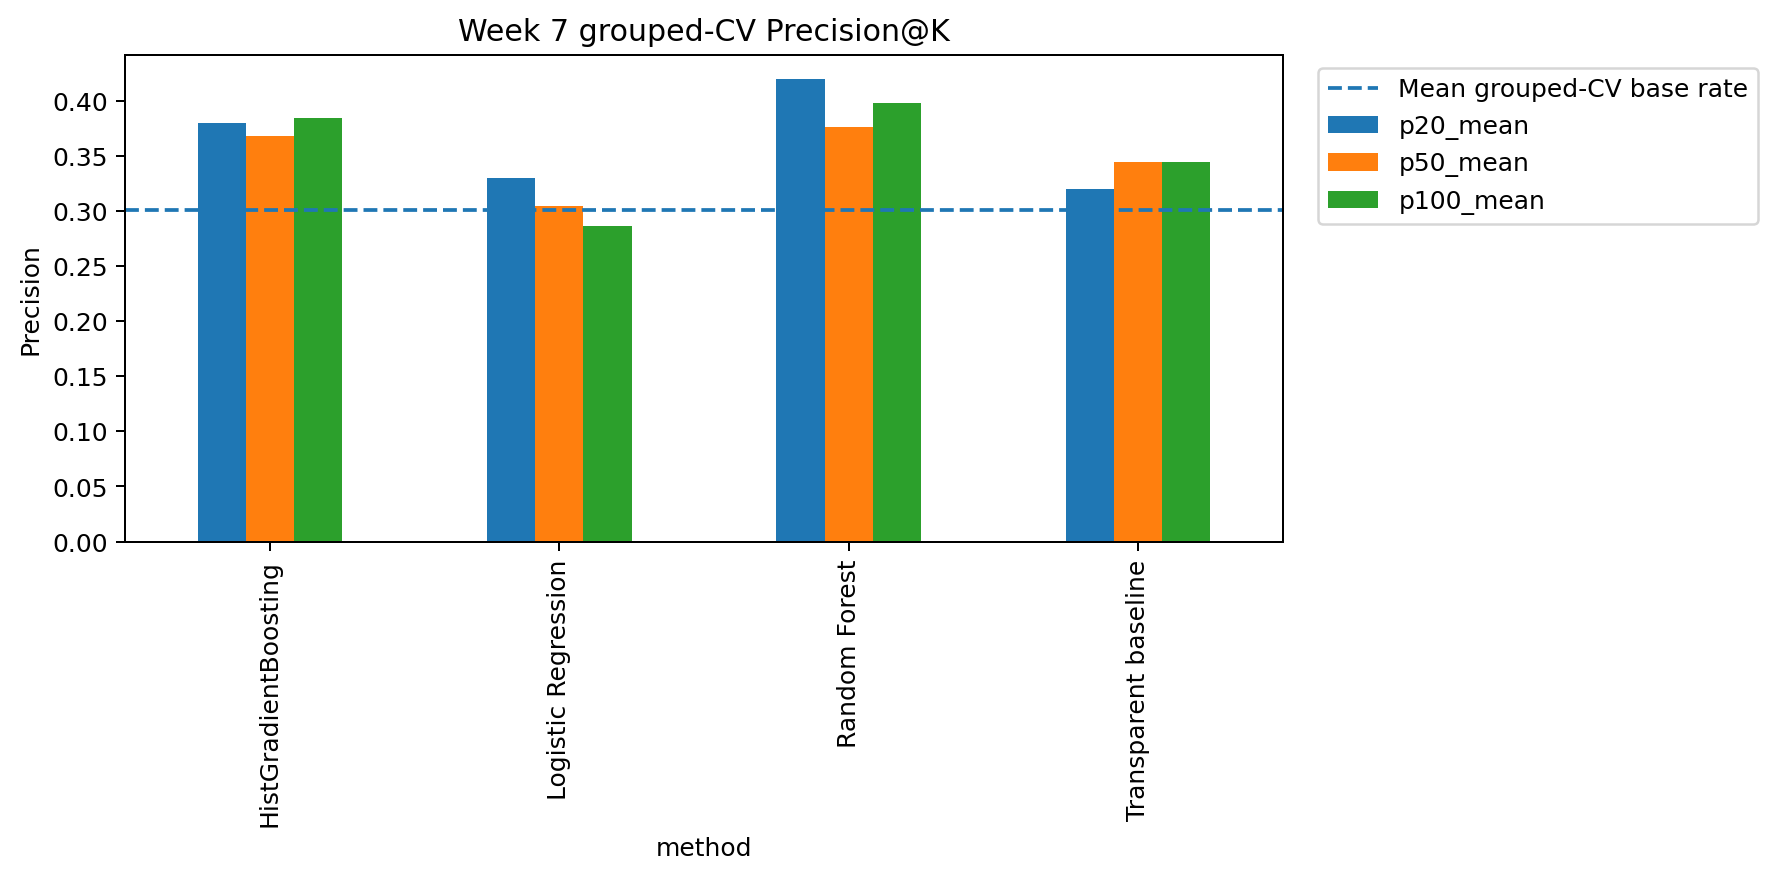

The chart compares the models at realistic review capacities.

| Method | Mean AP | P@20 | P@50 |
|---|---:|---:|---:|
| Transparent baseline | 0.3476 | 32.0% | 34.4% |
| Logistic Regression | 0.3171 | 33.0% | 30.4% |
| Random Forest | **0.3616** | **39.0%** | **36.8%** |
| HistGradientBoosting | 0.3575 | 32.0% | 35.2% |

>Random Forest achieved the strongest final grouped-CV result under the declared selection rule and also led the learned alternatives at Precision@20 and Precision@50.

---

### 4. One honest result

>The improvement is **measurable, but modest and variable**.

>Random Forest improved mean Average Precision from **0.3476 for the transparent baseline to 0.3616**, while Precision@50 increased from **34.4% to 36.8%**.

>However, performance varies substantially across held-out client groups. Precision@50 lift ranges from approximately **0.69× to 2.01× across the grouped folds**.

>So my result is not that the model can reliably predict every future decline.

>The defensible conclusion is that **historical search behavior provides directional value for ordering a limited human-review queue, but the evidence does not support autonomous editorial action or universal future-period reliability**.

---

### 5. Recommendation

I recommend using the model through the workflow:

**Prioritize → Inspect → Diagnose → Decide**

>A high score determines **review order**, not the editorial action.

A reviewer may decide to:

- review now;
- protect and diagnose;
- inspect click capture and search intent;
- monitor;
- or dismiss the recommendation.

>The model should not automatically rewrite, refresh, delete, merge, redirect, or change metadata.

###**Closing message:**
>*The model's practical value is in helping FlyRank focus limited human attention more systematically, while keeping consequential content decisions under human control.*

## Shareable Cuts

### Short Social Post — Methodology

>I completed a machine learning capstone using the pseudonymized FlyRank ML Internship dataset to study a practical content-review problem: **when a team cannot inspect every page, which pages should be reviewed first before search visibility declines?**

>Instead of treating the project as simple binary classification, I used predicted decline probabilities to build a **ranked human-review queue**. The final methodology separates 90 days of historical search behavior from a later 30-day outcome window, applies explicit history and stability requirements, prevents outcome-period leakage, and evaluates models using client-grouped cross-validation.

>I compared a transparent historical baseline with Logistic Regression, Random Forest, and HistGradientBoosting. Random Forest was selected using the predeclared mean grouped-CV Average Precision criterion, reaching **0.3616 mean AP, 39.0% Precision@20, and 36.8% Precision@50**.

>The most important result was not simply which algorithm won. Performance varied substantially across held-out clients, so I kept the conclusion narrow: the model provides **measured, directional decision support for prioritizing human review**, not an automated diagnosis or guarantee that editing a page will recover traffic.

>The project reinforced how much applied ML depends on the work around the model: defining the decision correctly, separating historical evidence from future outcomes, preventing leakage, establishing a meaningful baseline, and evaluating performance at the capacity where the system would actually be used.

---

### Employer-Facing Summary

>I built a leakage-audited machine learning ranking system that prioritizes which content pages should receive earlier human review using historical search-performance signals from the pseudonymized FlyRank ML Internship dataset. I designed a 90-day historical feature window and separate 30-day outcome period, compared a transparent baseline with Logistic Regression, Random Forest, and HistGradientBoosting under client-grouped validation, and selected Random Forest using a predeclared Average Precision criterion. The final model achieved **0.3616 mean grouped-CV Average Precision, 39.0% Precision@20, and 36.8% Precision@50**, showing measurable but client-variable improvement that supports human review prioritization rather than autonomous editorial action.

## Self-check

Before you submit, confirm each line honestly:

- [ - ] Every section above is filled — markdown thinking AND the code that backs it
- [ - ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ - ] No client names, URLs, or private queries anywhere
- [ - ] My claims use careful words: observed, measured, directional, decision-support
- [ - ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ - ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ - ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
